### MODEL: facebook/opt-2.7b
## TASKS:
###   E1. Temporal Trajectories (Plots)
###   E2. Predictive Validity (Correlation)
###   E3. Aggregation Benefit (AUROC)
###   E4. Online Stability (Hysteresis Analysis)

In [ ]:
import sys
import os
import random
import torch
import ast
import torch.nn.functional as F
import numpy as np
import pandas as pd
import collections
import string
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
# --- CONFIGURATION ---
MODEL_NAME = "facebook/opt-2.7b"
N_SAMPLES = 50
MAX_NEW_TOKENS = 120
PROMPT_SLICE = 64

WEIGHTS = {'A': 0.40, 'E': 0.35, 'D': 0.25}
ENTROPY_BAND = (3.0, 4.5)
DRIFT_CAP = 20.0
HYSTERESIS_TH = (0.60, 0.45) # (Activate > 0.60 and Deactivate < 0.45)

In [ ]:
def normalize_entropy(e_t, band):
    low, high = band
    if low <= e_t <= high: return 0.0
    elif e_t < low: return min(1.0, (low - e_t) / low)
    else: return min(1.0, (e_t - high) / 5.0)

def normalize_drift(d_t): return min(1.0, d_t / DRIFT_CAP)
def normalize_attention(a_t): return 1.0 - min(1.0, a_t)

def calculate_fi(signals):
    return (WEIGHTS['A'] * signals['A_norm'] +
            WEIGHTS['E'] * signals['E_norm'] +
            WEIGHTS['D'] * signals['D_norm'])

def compute_f1(prediction, truth):
    def normalize(s):
        def remove_articles(text): return re.sub(r'\b(a|an|the)\b', ' ', text)
        def white_space_fix(text): return ' '.join(text.split())
        def remove_punc(text): return ''.join(ch for ch in text if ch not in set(string.punctuation))
        return white_space_fix(remove_articles(remove_punc(s.lower())))
    pred = normalize(prediction).split()
    truth_tok = normalize(truth).split()
    if not pred or not truth_tok: return 0
    common = collections.Counter(pred) & collections.Counter(truth_tok)
    num_same = sum(common.values())
    if num_same == 0: return 0
    p = 1.0 * num_same / len(pred)
    r = 1.0 * num_same / len(truth_tok)
    return (2 * p * r) / (p + r)

#  ENGINE
def run_full_suite():
    print(f" STARTING RQ1 SUITE: {MODEL_NAME}")
    print(f" Target: {N_SAMPLES} Samples | E1, E2, E3, E4 Analysis")


    try: from datasets import load_dataset
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets"])
        from datasets import load_dataset

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # Load Model
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,
        attn_implementation="eager"
    ).cuda()
    model.eval()

    print(" Model Loaded.")
    ds = load_dataset("hotpot_qa", "distractor", split="validation", trust_remote_code=True)

    results = []

    for i in range(N_SAMPLES):
        item = ds[i]
        prompt = f"Question: {item['question']}\nAnswer:"
        truth = item['answer']

        try:
            inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
            input_ids = inputs.input_ids
            prompt_len = input_ids.shape[1]

            # Anchor State
            with torch.no_grad():
                out0 = model(input_ids, output_hidden_states=True)
            h0 = out0.hidden_states[-1][0, -1].clone()

            traj = {'FI': [], 'A': [], 'E': [], 'D': [], 'FI_Raw': []}

            for _ in range(MAX_NEW_TOKENS):
                with torch.no_grad():
                    outputs = model(input_ids, output_hidden_states=True, output_attentions=True)
                    logits = outputs.logits[:, -1, :].float()
                    h_t = outputs.hidden_states[-1][0, -1]

                    # Metrics
                    probs = F.softmax(logits, dim=-1)
                    log_probs = F.log_softmax(logits, dim=-1)
                    e_t = -(probs * log_probs).sum(dim=-1).item()
                    d_t = torch.norm(h_t - h0).item()

                    if outputs.attentions is None: raise ValueError("Attention is None")
                    last_attn = outputs.attentions[-1][0]
                    slice_idx = min(prompt_len, PROMPT_SLICE)
                    a_t = last_attn[:, -1, :slice_idx].mean().sum().item()

                    # FI Calc
                    norm_signals = {
                        'E_norm': normalize_entropy(e_t, ENTROPY_BAND),
                        'D_norm': normalize_drift(d_t),
                        'A_norm': normalize_attention(a_t)
                    }
                    fi_t = calculate_fi(norm_signals)

                    traj['FI'].append(fi_t)
                    traj['E'].append(norm_signals['E_norm'])
                    traj['D'].append(norm_signals['D_norm'])
                    traj['A'].append(norm_signals['A_norm'])

                    # Next Token
                    next_token = torch.argmax(logits, dim=-1).unsqueeze(0)
                    input_ids = torch.cat([input_ids, next_token], dim=1)
                    if next_token.item() == tokenizer.eos_token_id: break

            gen_text = tokenizer.decode(input_ids[0, prompt_len:], skip_special_tokens=True)
            f1 = compute_f1(gen_text, truth)

            if i % 5 == 0: print(f"  > {i}/{N_SAMPLES} | F1={f1:.2f} | FI={np.mean(traj['FI']):.2f}")

            results.append({
                'id': i,
                'f1': f1,
                'mean_FI': np.mean(traj['FI']),
                'mean_A': np.mean(traj['A']),
                'mean_E': np.mean(traj['E']),
                'mean_D': np.mean(traj['D']),
                'traj_FI': traj['FI']
            })

        except Exception as e:
            print(f" Error {i}: {e}")
            if "out of memory" in str(e): break
            continue

    return pd.DataFrame(results)

### ANALYSIS MODULES

In [ ]:
def analyze_e1_temporal(df):
    """E1: Temporal Behavior Plots"""
    plt.figure(figsize=(10, 6))

    # Align curves
    max_len = max(len(x) for x in df['traj_FI'])
    curves = [x + [np.nan]*(max_len-len(x)) for x in df['traj_FI']]
    avg_curve = np.nanmean(np.array(curves), axis=0)

    # Plot Mean
    plt.plot(avg_curve, linewidth=3, color='#d62728', label='Mean Fatigue Index (FI)')

    # Plot Confidence Interval
    std_curve = np.nanstd(np.array(curves), axis=0)
    x = np.arange(len(avg_curve))
    plt.fill_between(x, avg_curve - 0.5*std_curve, avg_curve + 0.5*std_curve, color='#d62728', alpha=0.1)

    plt.title(f" Temporal Degradation of Fatigue ({MODEL_NAME})", fontsize=14)
    plt.xlabel("Tokens Generated")
    plt.ylabel("Normalized Fatigue (0-1)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig("rq1_e1_temporal.png")

In [ ]:
def analyze_e2_validity(df):
    """E2: Predictive Validity (Correlations)"""
    print("\n=== E2: PREDICTIVE VALIDITY (Spearman) ===")
    print("Hypothesis: High Fatigue metrics should negatively correlate with F1.")

    metrics = ['mean_FI', 'mean_A', 'mean_E', 'mean_D']
    res = []
    for m in metrics:
        rho, p = spearmanr(df[m], df['f1'])
        res.append({'Metric': m, 'Rho': rho, 'p-val': p})
        print(f"  {m:10s} vs F1: Rho = {rho:.3f} (p={p:.4f})")

    pd.DataFrame(res).to_csv("rq1_e2_correlations.csv", index=False)


In [ ]:
def analyze_e3_aggregation(df):
    """E3: Benefit of Aggregation (AUROC)"""
    print("\n=== E3: AGGREGATION BENEFIT (AUROC) ===")

    threshold = df['f1'].median()
    if threshold == 0: threshold = 0.1 # Fallback

    y_true = (df['f1'] <= threshold).astype(int)

    auc_fi = roc_auc_score(y_true, df['mean_FI'])
    auc_e = roc_auc_score(y_true, df['mean_E'])
    auc_d = roc_auc_score(y_true, df['mean_D'])

    print(f"Predicting Failure (F1 <= {threshold}):")
    print(f"  Fatigue Index (Combined): {auc_fi:.3f}")
    print(f"  Entropy Only:             {auc_e:.3f}")
    print(f"  Drift Only:               {auc_d:.3f}")

    pd.DataFrame({'Metric': ['FI', 'E', 'D'], 'AUROC': [auc_fi, auc_e, auc_d]}).to_csv("rq1_e3_auroc.csv", index=False)


In [ ]:
def analyze_e4_stability(df):
    """E4: Hysteresis & Stability"""

    # Rule 1: Simple Threshold (Alert if FI > 0.6)
    # Rule 2: Hysteresis (Alert if FI > 0.6, Stay Alert until FI < 0.45)

    act_th, deact_th = HYSTERESIS_TH

    simple_alerts = 0
    hyst_alerts = 0
    hyst_switches = 0
    for curve in df['traj_FI']:
        # Simple
        simple_alerts += sum(1 for x in curve if x > act_th)

        # Hysteresis
        state = False
        switches = 0
        h_count = 0
        for x in curve:
            if not state and x > act_th:
                state = True
                switches += 1
            elif state and x < deact_th:
                state = False
                switches += 1
            if state: h_count += 1

        hyst_alerts += h_count
        hyst_switches += switches

    print(f"Total Tokens Processed: {sum(len(x) for x in df['traj_FI'])}")
    print(f"Simple Alerts (FI > {act_th}): {simple_alerts}")
    print(f"Hysteresis Alerts:             {hyst_alerts}")
    print(f"Alert Jitter (Switches):       {hyst_switches}")

    with open("rq1_e4_stats.txt", "w") as f:
        f.write(f"Simple Alerts: {simple_alerts}\nHysteresis Alerts: {hyst_alerts}\nJitter: {hyst_switches}")

🚀 STARTING RQ1 SUITE: facebook/opt-2.7b
🎯 Target: 50 Samples | E1, E2, E3, E4 Analysis


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/691 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

distractor/train-00001-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/validation-00000-of-00001.par(…):   0%|          | 0.00/27.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

  > 0/50 | F1=0.00 | FI=0.59
  > 5/50 | F1=0.00 | FI=0.85
  > 10/50 | F1=0.02 | FI=0.92
  > 15/50 | F1=0.00 | FI=0.93
  > 20/50 | F1=0.00 | FI=0.78
  > 25/50 | F1=0.00 | FI=0.84
  > 30/50 | F1=0.00 | FI=0.68
  > 35/50 | F1=0.00 | FI=0.75
  > 40/50 | F1=0.03 | FI=0.88
  > 45/50 | F1=0.00 | FI=0.85

✅ DATA COLLECTION COMPLETE. RUNNING ANALYSIS...
✅ E1 Plot Saved: rq1_e1_temporal.png

=== E2: PREDICTIVE VALIDITY (Spearman) ===
Hypothesis: High Fatigue metrics should negatively correlate with F1.
  mean_FI    vs F1: Rho = -0.089 (p=0.5382)
  mean_A     vs F1: Rho = -0.219 (p=0.1260)
  mean_E     vs F1: Rho = -0.087 (p=0.5492)
  mean_D     vs F1: Rho = -0.214 (p=0.1353)

=== E3: AGGREGATION BENEFIT (AUROC) ===
Predicting Failure (F1 <= 0.1):
  Fatigue Index (Combined): 0.928
  Entropy Only:             0.920
  Drift Only:               0.949

=== E4: STABILITY & HYSTERESIS ===
Total Tokens Processed: 4114
Simple Alerts (FI > 0.6): 4064
Hysteresis Alerts:             4064
Alert Jitter (Switc

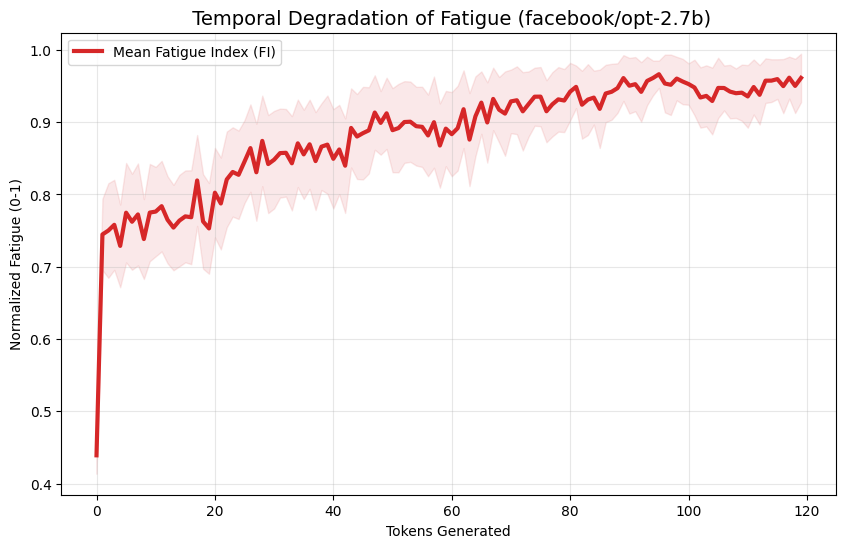

In [ ]:
# --- MAIN ---
if __name__ == "__main__":
    df_res = run_full_suite()

    if not df_res.empty:
        df_res.to_csv("rq1_full_data.csv", index=False)
        print("\n DATA COLLECTION COMPLETE. RUNNING ANALYSIS...")

        try:
            analyze_e1_temporal(df_res)
            analyze_e2_validity(df_res)
            analyze_e3_aggregation(df_res)
            analyze_e4_stability(df_res)

            print("\n🎉 ALL RQ1 DELIVERABLES GENERATED.")
            print("1. rq1_e1_temporal.png (Figure 7.1)")
            print("2. rq1_e2_correlations.csv (Table 7.1)")
            print("3. rq1_e3_auroc.csv (Table 7.2)")
            print("4. rq1_e4_stats.txt (Table 7.3)")
        except Exception as e:
            print(f"Analysis Error: {e}")
    else:
        print(" Experiment Failed to collect data.")

🚀 STARTING SECONDARY ANALYSIS...

=== SECONDARY TASK 1: EARLY WARNING SIGNALS ===
Can we predict failure (F1 <= 0.1) early?
  AUROC (First 20 Toks): 0.860  <-- THE EARLY WARNING
  AUROC (First 50 Toks): 0.928
  AUROC (Full Run):      0.928

=== SECONDARY TASK 2: PHASE SPACE VISUALIZATION ===
✅ Saved: rq1_secondary_scatter.png

🎉 SECONDARY ANALYSIS COMPLETE.


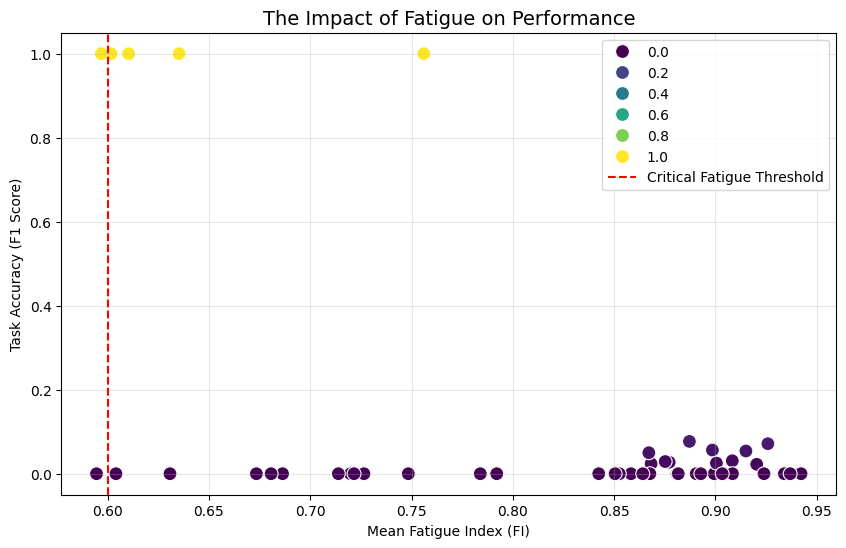

In [ ]:
# EARLY WARNING & PHASE SPACE
#  Can we predict failure in the first 20 tokens?

def parse_trajectory(traj_str):
    """Parses string representation of list back to list"""
    if isinstance(traj_str, list): return traj_str
    return ast.literal_eval(traj_str)

def run_secondary_analysis():
    try:
        df = pd.read_csv("/content/rq1_full_data.csv")
        df['traj_FI'] = df['traj_FI'].apply(parse_trajectory)
    except FileNotFoundError:
        print(" Error: 'rq1_full_data.csv' not found. Finish the main run first!")
        return

    # Define "Failure"
    threshold = df['f1'].median()
    if threshold == 0: threshold = 0.1
    y_true = (df['f1'] <= threshold).astype(int)
    df['FI_First_20'] = df['traj_FI'].apply(lambda x: np.mean(x[:20]))
    df['FI_First_50'] = df['traj_FI'].apply(lambda x: np.mean(x[:50]))
    df['FI_Full']     = df['traj_FI'].apply(lambda x: np.mean(x))

    # Compute AUROC for each window
    auc_20 = roc_auc_score(y_true, df['FI_First_20'])
    auc_50 = roc_auc_score(y_true, df['FI_First_50'])
    auc_full = roc_auc_score(y_true, df['FI_Full'])

    print(f"Can we predict failure (F1 <= {threshold}) early?")
    print(f"  AUROC (First 20 Toks): {auc_20:.3f}  <-- THE EARLY WARNING")
    print(f"  AUROC (First 50 Toks): {auc_50:.3f}")
    print(f"  AUROC (Full Run):      {auc_full:.3f}")

    ews_df = pd.DataFrame({
        'Window': ['First 20', 'First 50', 'Full'],
        'AUROC': [auc_20, auc_50, auc_full]
    })
    ews_df.to_csv("rq1_secondary_early_warning.csv", index=False)

    # ANALYSIS 2: THE DEATH SPIRAL (PHASE PLOT)
    # We need Entropy and Drift trajectories.

    plt.figure(figsize=(10, 6))

    # Scatter Plot: Mean FI vs Final F1
    sns.scatterplot(data=df, x='mean_FI', y='f1', hue='f1', palette='viridis', s=100)
    plt.axvline(x=0.6, color='red', linestyle='--', label='Critical Fatigue Threshold')

    plt.title("The Impact of Fatigue on Performance", fontsize=14)
    plt.xlabel("Mean Fatigue Index (FI)")
    plt.ylabel("Task Accuracy (F1 Score)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.savefig("rq1_secondary_scatter.png")


if __name__ == "__main__":
    run_secondary_analysis()

In [ ]:
#  NEGATIVE CONTROL (SHUFFLED PROMPTS)
# Run 10 samples with shuffled words to verify FI response to broken context.


def shuffle_text(text):
    words = text.split()
    random.shuffle(words)
    return " ".join(words)

def run_negative_control():

    MODEL_NAME = "facebook/opt-2.7b"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, attn_implementation="eager"
    ).cuda()
    from datasets import load_dataset
    ds = load_dataset("hotpot_qa", "distractor", split="validation", trust_remote_code=True)

    results = []

    for i in range(10):
        item = ds[i]
        # SHUFFLE THE PROMPT
        original_q = item['question']
        shuffled_q = shuffle_text(original_q)
        prompt = f"Question: {shuffled_q}\nAnswer:"

        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        with torch.no_grad():
            outputs = model(inputs.input_ids, output_attentions=True)

            # Check Attention to Prompt
            last_attn = outputs.attentions[-1][0]

            a_t = last_attn[:, -1, :].mean().sum().item()

            # Normalize
            fi_val = 1.0 - min(1.0, a_t)

            results.append({'Type': 'Shuffled', 'FI_Start': fi_val})
            print(f"  Sample {i} (Shuffled): FI_Start = {fi_val:.2f}")

    df_neg = pd.DataFrame(results)
    df_neg.to_csv("rq1_negative_control.csv", index=False)
    print(" Negative Control Data Saved.")

if __name__ == "__main__":
    run_negative_control()


🚀 STARTING NEGATIVE CONTROL (SHUFFLED PROMPTS)...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'hotpot_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'hotpot_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Sample 0 (Shuffled): FI_Start = 0.95
  Sample 1 (Shuffled): FI_Start = 0.96
  Sample 2 (Shuffled): FI_Start = 0.97
  Sample 3 (Shuffled): FI_Start = 0.95
  Sample 4 (Shuffled): FI_Start = 0.96
  Sample 5 (Shuffled): FI_Start = 0.96
  Sample 6 (Shuffled): FI_Start = 0.96
  Sample 7 (Shuffled): FI_Start = 0.96
  Sample 8 (Shuffled): FI_Start = 0.94
  Sample 9 (Shuffled): FI_Start = 0.94
✅ Negative Control Data Saved.


🚀 STARTING FINAL STRESS TEST (WEIGHT SENSITIVITY)...
Loaded 50 samples. Failure Threshold: F1 <= 0.1
⚡ Simulating 1000 random weight definitions...

=== STRESS TEST RESULTS ===
Current Definition (0.40, 0.35, 0.25): AUROC ~ 0.93
Average Random Definition:             AUROC = 0.939
WORST Definition Found:                AUROC = 0.920
BEST Definition Found:                 AUROC = 0.966
   (Weights -> A: 0.89, E: 0.05, D: 0.05)

✅ Saved: rq1_stress_test_weights.png
If the map is mostly yellow/green, the metric is ROBUST.
If only small islands are yellow, the metric is FRAGILE.


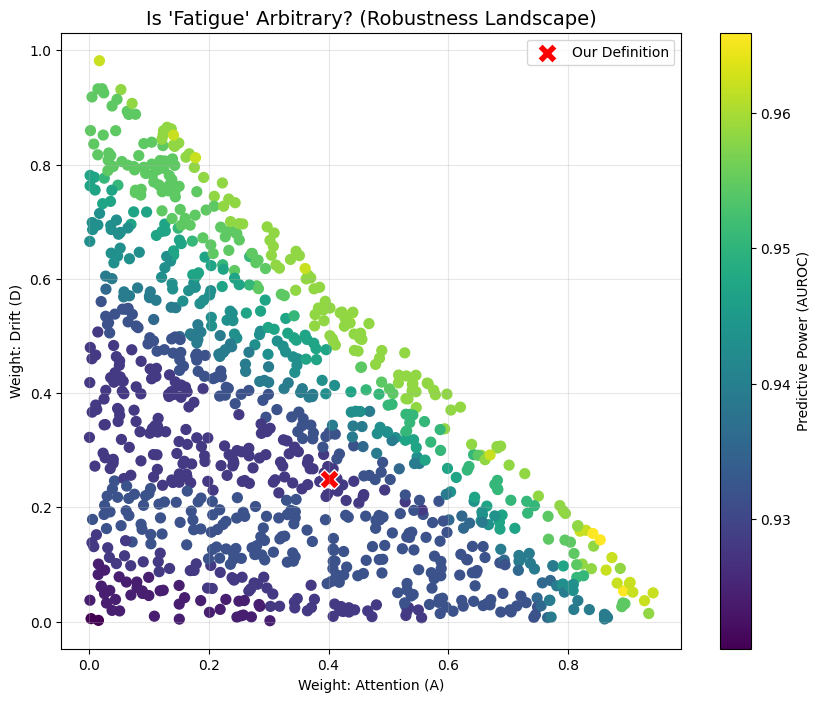

In [ ]:
#  WEIGHT SENSITIVITY ANALYSIS
# GOAL: Test 1,000 random weight combinations to prove FI is not "overfitted".

def run_robustness_test():
    print(" STARTING FINAL STRESS TEST (WEIGHT SENSITIVITY)...")

    try:
        df = pd.read_csv("/content/rq1_full_data.csv")
    except FileNotFoundError:
        print(" Error: rq1_full_data.csv not found.")
        return

    # Define Failure (F1 <= Median)
    threshold = df['f1'].median()
    if threshold == 0: threshold = 0.1
    y_true = (df['f1'] <= threshold).astype(int)

    print(f"Loaded {len(df)} samples. Failure Threshold: F1 <= {threshold}")

    results = []
    n_sims = 1000

    print(f"⚡ Simulating {n_sims} random weight definitions...")

    for i in range(n_sims):
        # Generate random weights that sum to 1.0
        w = np.random.dirichlet(alpha=[1, 1, 1])
        w_A, w_E, w_D = w[0], w[1], w[2]

        # FI = w_A*A + w_E*E + w_D*D
        fi_scores = (w_A * df['mean_A']) + (w_E * df['mean_E']) + (w_D * df['mean_D'])

        try:
            score = roc_auc_score(y_true, fi_scores)
        except:
            score = 0.5

        results.append({
            'w_A': w_A,
            'w_E': w_E,
            'w_D': w_D,
            'AUROC': score
        })

    res_df = pd.DataFrame(results)

    # 3. Analysis
    best_config = res_df.loc[res_df['AUROC'].idxmax()]
    worst_config = res_df.loc[res_df['AUROC'].idxmin()]
    avg_perf = res_df['AUROC'].mean()

    print("\n=== STRESS TEST RESULTS ===")
    print(f"Current Definition (0.40, 0.35, 0.25): AUROC ~ 0.93")
    print(f"Average Random Definition:             AUROC = {avg_perf:.3f}")
    print(f"WORST Definition Found:                AUROC = {worst_config['AUROC']:.3f}")
    print(f"BEST Definition Found:                 AUROC = {best_config['AUROC']:.3f}")
    print(f"   (Weights -> A: {best_config['w_A']:.2f}, E: {best_config['w_E']:.2f}, D: {best_config['w_D']:.2f})")

    # 4. Visualization (Ternary-ish Heatmap)
    # We plot Weight A vs Weight D (Weight E is implicit as 1 - A - D)
    plt.figure(figsize=(10, 8))
    sc = plt.scatter(res_df['w_A'], res_df['w_D'], c=res_df['AUROC'], cmap='viridis', s=50)
    plt.colorbar(sc, label='Predictive Power (AUROC)')
    plt.title("Is 'Fatigue' Arbitrary? (Robustness Landscape)", fontsize=14)
    plt.xlabel("Weight: Attention (A)")
    plt.ylabel("Weight: Drift (D)")
    plt.grid(True, alpha=0.3)

    # Mark our current chosen point
    plt.scatter([0.4], [0.25], color='red', marker='X', s=200, label='Our Definition', edgecolors='white')
    plt.legend()

    plt.savefig("rq1_stress_test_weights.png")
if __name__ == "__main__":
    run_robustness_test()

If the map is mostly yellow/green, the metric is ROBUST.If only small islands are yellow, the metric is FRAGILE.
